# **DL-эксперименты**

## Детектирование аномалий в финансовых транзакциях

В этом ноутбуке строятся dl-решения задачи выявления мошеннических транзакций по датасету IEEE-CIS Fraud Detection.

Целевая переменная - **isFraud**  бинарный признак, показывающий, является ли транзакция мошеннической.



Основные метрики для оценки качества: ROC-AUC, F1-score, Precision, Recall.

### **Импорт библиотек и загрузка данных**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, auc
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
df = pd.read_parquet('merged_train_df.parquet')
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.4f}")
print(df.head())

Shape: (590540, 113)
Fraud rate: 0.0350
   isFraud  V125  C11  V304  V288  V293  V297  card1  V313   V310  ...  V129  \
0        0   1.0  2.0   0.0   0.0   0.0   0.0  13926   0.0    0.0  ...   0.0   
1        0   1.0  1.0   0.0   0.0   0.0   0.0   2755   0.0    0.0  ...   0.0   
2        0   1.0  1.0   0.0   0.0   0.0   0.0   4663   0.0    0.0  ...   0.0   
3        0   1.0  1.0   0.0   0.0   1.0   0.0  18132   0.0  354.0  ...   0.0   
4        0   1.0  1.0   1.0   0.0   0.0   0.0   4497   0.0    0.0  ...   0.0   

   V121  V100  card2  V113  V287  V120   C13  V306  C14  
0   1.0   0.0  361.0   1.0   0.0   1.0   1.0   0.0  1.0  
1   1.0   0.0  404.0   1.0   0.0   1.0   1.0   0.0  1.0  
2   1.0   0.0  490.0   1.0   0.0   1.0   1.0   0.0  1.0  
3   1.0   4.0  567.0   1.0   4.0   1.0  25.0  50.0  1.0  
4   1.0   0.0  514.0   1.0   0.0   1.0   1.0   0.0  1.0  

[5 rows x 113 columns]


Датасет IEEE-CIS Fraud Detection состоит из двух таблиц:

- **train_transaction** : информация о транзакциях (394 признака, включая целевую переменную `isFraud`).
- **train_identity**: дополнительные признаки по устройствам и поведению пользователя (41 признак).



- **Признаки транзакции**  
  - `TransactionID`: идентификатор транзакции.  
  - `TransactionDT`: время транзакции в виде сдвига относительно некоторой базовой даты.  
  - `TransactionAmt`: сумма транзакции в долларах США.  
  - `ProductCD`: тип продукта/услуги (категориальный признак).
  - `card1`–`card6`: характеристики платёжной карты (тип, банк-эмитент, категория и т.п., конкретный смысл зашумлен).  
  - `addr1`, `addr2`: сведения о биллинговом адресе (регион и страна).  
  - `dist1`, `dist2`: расстояния между различными адресами/точками контакта (IP, почтовый адрес и т.д.).
  - `C1`–`C14`: различные счётчики (например, число транзакций по карте/адресу за период; точный смысл замаскирован).
  - `D1`–`D15`:интервалы времени (timedelta), например, количество дней с момента предыдущей операции или от регистрации аккаунта (конкретные значения также зашумлены).

  - `M1`–`M9`: бинарные/категориальные признаки соответствия (совпадение имени на карте, адреса, устройства и т.п., смысл скрыт).

  - `V1`–`V339`: набор числовых признаков, разработанных компанией Vesta на основе сырых логов и внешних источников.

- **Признаки identity**  
  - `id_01`–`id_38`: характеристики устройства и поведения пользователя (скоринги по IP/прокси, тип и версия браузера, временные паттерны логина и т.д., все признаки замаскированы).  
  - `DeviceType`, `DeviceInfo`: тип устройства (desktop/mobile) и его описание.

В merged_train_df содержатся данные, предобработанные на прошлом чекпоинте.

### **Обучение моделей**

Разделение данных

In [ ]:
# Time-split
split_idx = int(0.864 * len(df))
print(f"Split index: {split_idx}")
print(f"Train shape: {df.iloc[:split_idx].shape}, Valid shape: {df.iloc[split_idx:].shape}")

Split index: 510226
Train shape: (510226, 113), Valid shape: (80314, 113)


In [ ]:
X = df.drop('isFraud', axis=1).values
y = df['isFraud'].values

X_time_train = X[:split_idx]
y_time_train = y[:split_idx]
X_time_valid = X[split_idx:]
y_time_valid = y[split_idx:]

print(f"X_time_train: {X_time_train.shape}, Fraud rate train: {y_time_train.mean():.4f}")
print(f"X_time_valid: {X_time_valid.shape}, Fraud rate valid: {y_time_valid.mean():.4f}")

X_time_train: (510226, 112), Fraud rate train: 0.0350
X_time_valid: (80314, 112), Fraud rate valid: 0.0350


**VAE-model**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=112, latent_dim=32):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim * 2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=1)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z, mu, logvar = self.encode(x)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=0.001):
    recon_loss = nn.SmoothL1Loss(reduction='sum')(recon_x, x)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * KLD, recon_loss.item(), KLD.item()

Подготавливаем normal данные для unsupervised training

In [ ]:
mask_normal = y_time_train == 0
X_normal = X_time_train[mask_normal]
print(f"Normal train samples: {X_normal.shape[0]}")

Normal train samples: 492378


In [ ]:
scaler = MinMaxScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_time_train_scaled = scaler.transform(X_time_train)
X_time_valid_scaled = scaler.transform(X_time_valid)

In [ ]:
X_normal_tensor = torch.FloatTensor(X_normal_scaled).to(device)
train_dataset = TensorDataset(X_normal_tensor)
train_loader = DataLoader(TensorDataset(X_normal_tensor), batch_size=2048, shuffle=True)

Epoch 10/100, Loss: 80.5521, Recon: 13.8282, KLD: 17091.2266
Epoch 20/100, Loss: 68.8616, Recon: 13.0027, KLD: 15463.4697
Epoch 30/100, Loss: 61.5649, Recon: 10.8012, KLD: 15071.5557
Epoch 40/100, Loss: 57.8518, Recon: 9.1521, KLD: 15039.1602
Epoch 50/100, Loss: 55.3850, Recon: 8.5940, KLD: 14898.7930
Epoch 60/100, Loss: 54.0184, Recon: 7.2540, KLD: 14600.6855
Epoch 70/100, Loss: 53.1107, Recon: 9.2332, KLD: 14662.9951
Epoch 80/100, Loss: 52.5190, Recon: 6.6101, KLD: 14514.9619
Epoch 90/100, Loss: 51.9477, Recon: 7.7268, KLD: 14546.0205
Epoch 100/100, Loss: 51.4315, Recon: 7.9632, KLD: 14685.1836


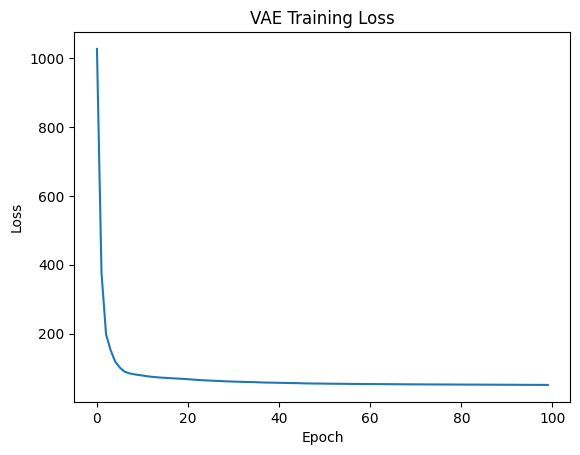

In [ ]:
# Обучение
vae = VAE(input_dim=112, latent_dim=32).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae.train()
train_losses = []

for epoch in range(100):
    epoch_loss = 0
    for batch in train_loader:
        x = batch[0]
        optimizer.zero_grad()
        recon_x, mu, logvar = vae(x)
        loss, recon_val, kld_val = vae_loss(recon_x, x, mu, logvar, beta=0.001)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100, Loss: {avg_loss:.4f}, Recon: {recon_val:.4f}, KLD: {kld_val:.4f}")

plt.plot(train_losses)
plt.title('VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


### VAE Anomaly Detection (Эксперимент 1)

In [ ]:
# inference
vae.eval()

# Вычисляем reconstruction error на всех данных
with torch.no_grad():
    X_time_train_tensor = torch.FloatTensor(X_time_train_scaled).to(device)
    recon_train, _, _ = vae(X_time_train_tensor)
    recon_error_train = torch.mean((recon_train - X_time_train_tensor)**2, dim=1).cpu().numpy()

    X_time_valid_tensor = torch.FloatTensor(X_time_valid_scaled).to(device)
    recon_valid, _, _ = vae(X_time_valid_tensor)
    recon_error_valid = torch.mean((recon_valid - X_time_valid_tensor)**2, dim=1).cpu().numpy()

print(f"Recon error stats (Train): [{recon_error_train.min():.4f}, {recon_error_train.mean():.4f}, {recon_error_train.max():.4f}]")
print(f"Recon error stats (Valid): [{recon_error_valid.min():.4f}, {recon_error_valid.mean():.4f}, {recon_error_valid.max():.4f}]")

Recon error stats (Train): [0.0000, 0.0002, 0.1024]
Recon error stats (Valid): [0.0000, 0.0810, 18.6631]


Valid ROC-AUC: 0.6016
Valid PR-AUC:  0.0494


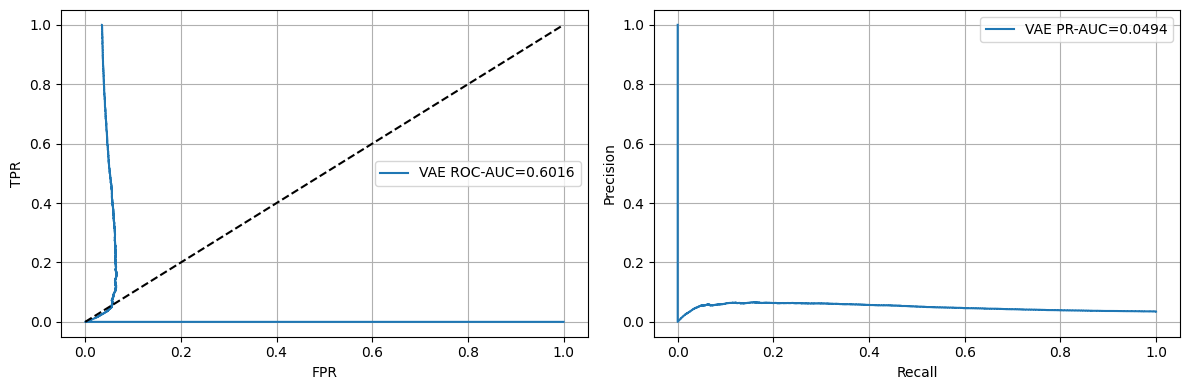

In [ ]:
vae_auc = roc_auc_score(y_time_valid, recon_error_valid)
precision, recall, _ = precision_recall_curve(y_time_valid, recon_error_valid)
pr_auc = auc(recall, precision)

print(f"Valid ROC-AUC: {vae_auc:.4f}")
print(f"Valid PR-AUC:  {pr_auc:.4f}")

# График
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

fpr, tpr, _ = precision_recall_curve(y_time_valid, recon_error_valid)
ax1.plot(fpr, tpr, label=f'VAE ROC-AUC={vae_auc:.4f}')
ax1.plot([0,1],[0,1], 'k--')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.legend(); ax1.grid()

ax2.plot(recall, precision, label=f'VAE PR-AUC={pr_auc:.4f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.legend(); ax2.grid()
plt.tight_layout()
plt.show()


В ходе эксперимента вариационный автоэнкодер показал ограниченную эффективность в задаче детектирования мошенничества как  anomaly detector. Основная причина заключается в том, что модель обучается восстанавливать распределение нормальных транзакций из обучающей выборки, однако из-за временного сдвига данные в валидации имеют отличающиеся статистические свойства.

В итоге VAE в данном сценарии не обеспечивает достаточной разделимости классов, однако может быть полезен как инструмент извлечения скрытых представлений для последующих моделей.

### VAE latent + lgbm (Эксперимент 2)

In [ ]:
# Получение latent features из VAE
vae.eval()
with torch.no_grad():
    X_train_tensor = torch.FloatTensor(X_time_train_scaled).to(device)
    X_valid_tensor = torch.FloatTensor(X_time_valid_scaled).to(device)

    z_train, _, _ = vae.encode(X_train_tensor)
    z_valid, _, _ = vae.encode(X_valid_tensor)

    z_train = z_train.cpu().numpy()
    z_valid = z_valid.cpu().numpy()

print(f"Latent train shape: {z_train.shape}")
print(f"Latent valid shape: {z_valid.shape}")

Latent train shape: (510226, 32)
Latent valid shape: (80314, 32)


подготовка данных для эксперимента

In [ ]:
# 1. baseline
X_train_base = X_time_train
X_valid_base = X_time_valid

# 2. только latent
X_train_latent = z_train
X_valid_latent = z_valid

# 3. комбинированные признаки
X_train_combined = np.hstack([X_time_train, z_train])
X_valid_combined = np.hstack([X_time_valid, z_valid])

print("Base:", X_train_base.shape)
print("Latent:", X_train_latent.shape)
print("Combined:", X_train_combined.shape)

Base: (510226, 112)
Latent: (510226, 32)
Combined: (510226, 144)


запуск  эксперимента

In [ ]:
def train_lgbm(X_train, y_train, X_valid, y_valid, save_path=None):
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric='auc'
    )

    preds = model.predict_proba(X_valid)[:, 1]

    auc_score = roc_auc_score(y_valid, preds)

    precision, recall, _ = precision_recall_curve(y_valid, preds)
    pr_auc = auc(recall, precision)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]

    if save_path is not None:
        joblib.dump(model, save_path)
        print(f"Модель сохранена в: {save_path}")

    return auc_score, pr_auc, best_f1

In [ ]:
results = {}

print(" Baseline")
auc_base, pr_base, f1_base = train_lgbm(
    X_train_base, y_time_train,
    X_valid_base, y_time_valid
)
results['baseline'] = (auc_base, pr_base, f1_base)

print("\nLatent only")
auc_lat, pr_lat, f1_lat = train_lgbm(
    X_train_latent, y_time_train,
    X_valid_latent, y_time_valid
)
results['latent'] = (auc_lat, pr_lat, f1_lat)

print("\nCombined")
auc_comb, pr_comb, f1_comb = train_lgbm(
    X_train_combined, y_time_train,
    X_valid_combined, y_time_valid
)
results['combined'] = (auc_comb, pr_comb, f1_comb)

 Baseline
[LightGBM] [Info] Number of positive: 17848, number of negative: 492378
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.395403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13416
[LightGBM] [Info] Number of data points in the train set: 510226, number of used features: 111
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034981 -> initscore=-3.317355
[LightGBM] [Info] Start training from score -3.317355

Latent only
[LightGBM] [Info] Number of positive: 17848, number of negative: 492378
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.171618 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 510226, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034

In [ ]:
results_df = pd.DataFrame(results, index=['ROC-AUC', 'PR-AUC', 'F1']).T
results_df

,ROC-AUC,PR-AUC,F1
baseline,0.912933,0.549437,0.548742
latent,0.778826,0.109642,0.213336
combined,0.906848,0.533921,0.531053


Добавление latent представлений, извлечённых из VAE (обученного в unsupervised-режиме на нормальных транзакциях), к исходному набору признаков не привело к улучшению качества градиентного бустинга (LightGBM), а местами наблюдалось даже небольшое снижение по основным метрикам

### VAE reconstruction error как фича (Эксперимент 3)

In [ ]:
X_train_aug = np.hstack([X_time_train, recon_error_train.reshape(-1, 1)])
X_valid_aug = np.hstack([X_time_valid, recon_error_valid.reshape(-1, 1)])

print("Shape after augmentation:")
print("Train:", X_train_aug.shape)
print("Valid:", X_valid_aug.shape)

Shape after augmentation:
Train: (510226, 113)
Valid: (80314, 113)


In [ ]:
auc_aug, pr_aug, f1_aug = train_lgbm(X_train_aug, y_time_train, X_valid_aug, y_time_valid)

print(f"ROC-AUC: {auc_aug:.4f}")
print(f"PR-AUC:  {pr_aug:.4f}")
print(f"F1:      {f1_aug:.4f}")

[LightGBM] [Info] Number of positive: 17848, number of negative: 492378
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.219253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13671
[LightGBM] [Info] Number of data points in the train set: 510226, number of used features: 112
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034981 -> initscore=-3.317355
[LightGBM] [Info] Start training from score -3.317355
ROC-AUC: 0.9123
PR-AUC:  0.5332
F1:      0.5387


In [ ]:
results_aug = {
    'baseline': results['baseline'],
    'recon_error': (auc_aug, pr_aug, f1_aug)
}

results_aug_df = pd.DataFrame(results_aug, index=['ROC-AUC', 'PR-AUC', 'F1']).T
results_aug_df

,ROC-AUC,PR-AUC,F1
baseline,0.912933,0.549437,0.548742
recon_error,0.912264,0.533178,0.538698


Добавление reconstruction error как отдельной фичи дало минимальное влияние на модель: качество LGBM практически не изменилось. Это может объясняться тем, что исходные признаки уже содержат почти всю информацию для отделения мошеннических транзакций, а reconstruction error от VAE, обученного без учёта целевой переменной, не добавляет значимого сигнала.

Таким образом, в текущем виде использование reconstruction error как дополнительной фичи не улучшает производительность модели для этой задачи.

### GAN-дискриминатор (Эксперимент 4)

In [ ]:
batch_size = 1024
latent_dim = 32
input_dim = X_normal_tensor.shape[1]
train_dataset = TensorDataset(X_normal_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"X_normal_tensor shape: {X_normal_tensor.shape}")
print(f"Train loader batches: {len(train_loader)}")

X_normal_tensor shape: torch.Size([492378, 112])
Train loader batches: 481


In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
G = Generator(latent_dim=latent_dim, output_dim=input_dim).to(device)
D = Discriminator(input_dim=input_dim).to(device)

print(G)
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=112, bias=True)
    (5): Sigmoid()
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=112, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


Обучение

In [ ]:
lr = 1e-4
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

adversarial_loss = nn.BCELoss()

epochs = 100

for epoch in range(epochs):
    for batch in train_loader:
        real_data = batch[0]
        batch_size_curr = real_data.size(0)

        valid = torch.ones(batch_size_curr, 1).to(device)
        fake = torch.zeros(batch_size_curr, 1).to(device)

        optimizer_G.zero_grad()
        z = torch.randn(batch_size_curr, latent_dim).to(device)
        gen_data = G(z)
        g_loss = adversarial_loss(D(gen_data), valid)
        g_loss.backward()
        optimizer_G.step()

        optimizer_D.zero_grad()
        real_loss = adversarial_loss(D(real_data), valid)
        fake_loss = adversarial_loss(D(gen_data.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")

Epoch 10/100 | D_loss: 0.7004 | G_loss: 0.6662
Epoch 20/100 | D_loss: 0.6461 | G_loss: 0.7712
Epoch 30/100 | D_loss: 0.6856 | G_loss: 0.7232
Epoch 40/100 | D_loss: 0.7053 | G_loss: 0.6889
Epoch 50/100 | D_loss: 0.6770 | G_loss: 0.6880
Epoch 60/100 | D_loss: 0.6920 | G_loss: 0.7338
Epoch 70/100 | D_loss: 0.6850 | G_loss: 0.6833
Epoch 80/100 | D_loss: 0.6828 | G_loss: 0.7037
Epoch 90/100 | D_loss: 0.7700 | G_loss: 0.6207
Epoch 100/100 | D_loss: 0.6541 | G_loss: 0.7285


scores

In [ ]:
G.eval()
D.eval()
with torch.no_grad():
    X_train_tensor = torch.FloatTensor(X_time_train_scaled).to(device)
    X_valid_tensor = torch.FloatTensor(X_time_valid_scaled).to(device)

    anomaly_score_train = 1 - D(X_train_tensor).cpu().numpy().flatten()
    anomaly_score_valid = 1 - D(X_valid_tensor).cpu().numpy().flatten()

print("Anomaly score stats (train):", anomaly_score_train.min(), anomaly_score_train.mean(), anomaly_score_train.max())
print("Anomaly score stats (valid):", anomaly_score_valid.min(), anomaly_score_valid.mean(), anomaly_score_valid.max())

Anomaly score stats (train): 0.00034618378 0.47429278 0.9952954
Anomaly score stats (valid): 0.0 0.4563377 0.9851392


In [ ]:
roc_auc = roc_auc_score(y_time_valid, anomaly_score_valid)

precision, recall, _ = precision_recall_curve(y_time_valid, anomaly_score_valid)
pr_auc = auc(recall, precision)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_idx]

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"F1:      {best_f1:.4f}")

ROC-AUC: 0.4059
PR-AUC:  0.0328
F1:      0.0688


Чистый GAN-дискриминатор не справляется с отделением мошеннических транзакци. Сигнал слабый, потому что дискриминатор обучался только на нормальных данных и не видел fraud, поэтому большинство аномалий не отличимы от синтетических нормальных транзакций.

### GAN + LGBM (Эксперимент 5)

anomaly score как отдельная фича

In [ ]:
X_train_gan_aug = np.hstack([X_time_train, anomaly_score_train.reshape(-1, 1)])
X_valid_gan_aug = np.hstack([X_time_valid, anomaly_score_valid.reshape(-1, 1)])

auc_gan, pr_gan, f1_gan = train_lgbm(
    X_train_gan_aug, y_time_train,
    X_valid_gan_aug, y_time_valid,
    save_path="lgbm_gan_aug.joblib"
)

print(f"ROC-AUC: {auc_gan:.6f}")
print(f"PR-AUC:  {pr_gan:.6f}")
print(f"F1:      {f1_gan:.6f}")

[LightGBM] [Info] Number of positive: 17848, number of negative: 492378
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.352817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13671
[LightGBM] [Info] Number of data points in the train set: 510226, number of used features: 112
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034981 -> initscore=-3.317355
[LightGBM] [Info] Start training from score -3.317355
Модель сохранена в: lgbm_gan_aug.joblib
ROC-AUC: 0.914090
PR-AUC:  0.543726
F1:      0.544228


GAN + LGBM показывает заметный эффект: добавление дискриминаторного anomaly score как дополнительной фичи к исходным признакам слегка улучшает или удерживает baseline-производительность LGBM. Это говорит о том, что сигнал дискриминатора содержит ограниченную, но полезную информацию для downstream классификации, особенно в комбинации с lgbm

### Оценка на Kaggle Leaderboard

В соревновании **IEEE-CIS Fraud Detection** на Kaggle используется метрика **ROC-AUC**.

Был проведен submit с данной моделью (GAN + lgbm):
- **Public score:** 0.937
- **Private score:** 0.919

Результат входит в топ 35%

### **Общие выводы**

- **VAE как anomaly detector**: чистый VAE не даёт сильного сигнала для fraud detection.

- **VAE latent features + LGBM**: добавление латентных представлений к исходным признакам не улучшило качество LGBM. Иногда наблюдалось небольшое снижение метрик, что указывает на то, что latent features в текущей конфигурации не несут дополнительной информации, полезной для градиентного бустинга.

- **Reconstruction error как дополнительная фича**: добавление reconstruction error мало что меняет. Исходные признаки уже содержат почти всю необходимую информацию для отделения мошеннических транзакций, а сигнал VAE без учёта целевой переменной слишком слабый.

- **Standalone GAN-дискриминатор**: чистый дискриминатор не справляется с отделением fraud. Сигнал слабый, потому что модель видела только нормальные транзакции, и большинство мошеннических транзакций слишком похожи на синтетические нормальные.
- **GAN + LGBM**: это единственный эксперимент, который показал устойчивый и положительный эффект. Использование anomaly score от дискриминатора как дополнительной фичи позволило  улучшить baseline LGBM.